In [1]:
!pip install openpyxl arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.1 MB/s eta 0:00:00


In [2]:
# -----------------------------------------------------------------------------
# SETUP E IMPORT
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
from arch import arch_model
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

In [8]:
# =============================================================================
# CARICAMENTO DATI
# =============================================================================

# Configurazione file
file_path = 'Zeri_Tommaso.xlsx'
sheet_name = 'Ex.1'

# Lettura dati
# Si assume che la Colonna A sia la Data e la Colonna B i Log Prezzi
df = pd.read_excel(file_path, sheet_name=sheet_name)
df = df.iloc[:, [0, 1]]
df.columns = ['Date', 'LogPrice']

# Impostazione Data come indice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Calcolo Rendimenti (Log Returns)
# Poiché la colonna B è già il Log Prezzo, il rendimento è la differenza
df['logret'] = df['LogPrice'].diff()
df.dropna(inplace=True)

# Variabile 'data' per compatibilità con il resto dello script originale
data = df

# Variabile 'ticker' per i titoli dei grafici
ticker = "Zeri_Tommaso_Data"

# Mostra le prime righe per conferma
print("Dati caricati:")
print(data.head())

Dati caricati:
            LogPrice    logret
Date                          
2000-01-04  0.004000  0.004000
2000-01-05 -0.450075 -0.454075
2000-01-06 -0.839182 -0.389106
2000-01-07 -0.939597 -0.100415
2000-01-10 -0.847678  0.091919


In [9]:
# =============================================================================
# SELEZIONE MODELLO
# =============================================================================

#per i titoli dei grafici
#modello_usato = "GARCH(1,1)"
modello_usato = "GJR-GARCH(1,1,1)"
#modello_usato = "TARCH(1,1,1)"
#modello_usato = "EGARCH(1,1,1)"
#modello_usato = "APARCH(1,1,1)"

In [10]:
# --- FITTING DEL MODELLO ---

scaled_ret = data["logret"]*100

#model = arch_model(scaled_ret, vol="GARCH", p=1, q=1) #GARCH
model = arch_model(scaled_ret, vol="GARCH", p=1, o=1, q=1, dist="skewt" ) #GJR-GARCH
#model = arch_model(scaled_ret, vol="GARCH", p=1, o=1, q=1, power=1.0) #TARCH
#model = arch_model(scaled_ret, vol="EGARCH", p=1, o=1, q=1) #EGARCH
#model = arch_model(scaled_ret, vol="APARCH", p=1, o=1, q=1) #APARCH

results = model.fit(disp="off")
print(results.summary())


# --- SOMMARIO ORDINATO CON PANDAS ---

summary_df = pd.DataFrame({
    'Coefficient': results.params,
    'Std. Error': results.std_err,
    'T-Stat': results.tvalues,
    'P-Value': results.pvalues
})

# Arrotondiamo per pulizia (es. 4 cifre decimali)
summary_df = summary_df.round(4)

# Logica:
# < 0.01 (1%)  -> ***
# < 0.05 (5%)  -> **
# < 0.10 (10%) -> *
summary_df['Significant'] = summary_df['P-Value'].apply(
    lambda x: '***' if x < 0.01 else '**' if x < 0.05 else '*' if x < 0.10 else ''
)
print("--- Tabella Coefficienti GARCH ---")
print(summary_df)

                         Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                            logret   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -29391.2
Distribution:      Standardized Skew Student's t   AIC:                           58796.5
Method:                       Maximum Likelihood   BIC:                           58844.0
                                                   No. Observations:                 6580
Date:                           Sat, Jan 24 2026   Df Residuals:                     6579
Time:                                   11:29:49   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
--------------------------------------------

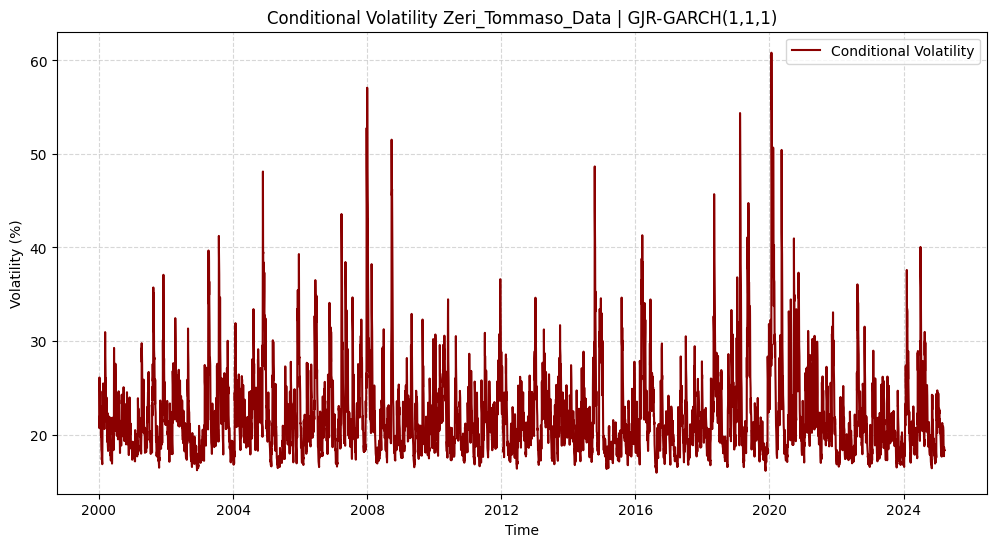

In [11]:
# --- GRAFICO VOLATILITÀ CONDIZIONALE ---
#estraggo conditional volatility
cond_vol = results.conditional_volatility

#plotto conditional volatility
plt.figure(figsize=(12, 6))
plt.plot(cond_vol.index, cond_vol, label="Conditional Volatility", color="darkred")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Volatility (%)")
plt.title(f"Conditional Volatility {ticker} | {modello_usato}")
plt.legend()

plt.show()

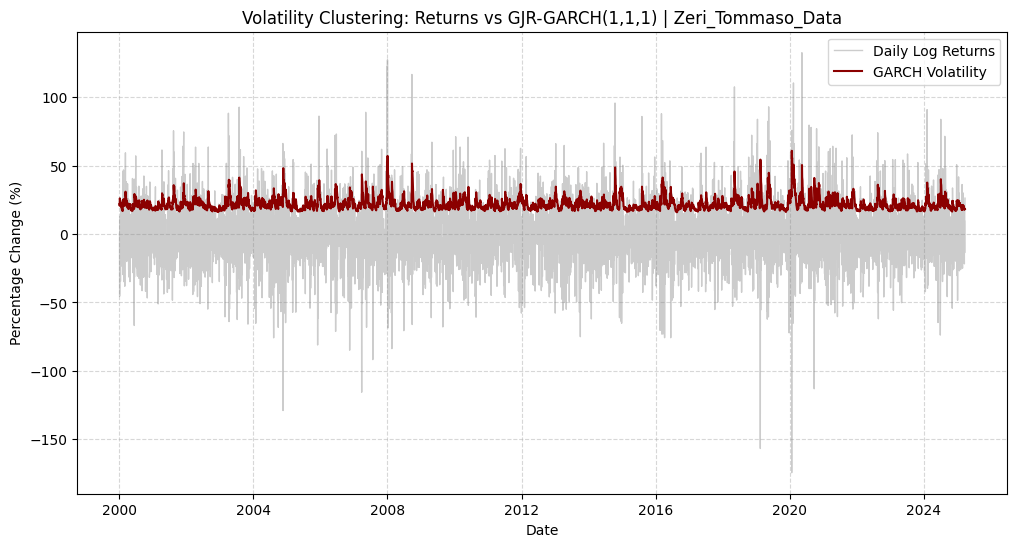

In [12]:
# --- CONFRONTO RETURNS VS VOLATILITY ---
#plotto confronto tra scaled log ret e cond vol
plt.figure(figsize=(12, 6))

plt.plot(scaled_ret.index, scaled_ret, label="Daily Log Returns", color="grey", alpha=0.4, linewidth=1)
plt.plot(cond_vol.index, cond_vol, label="GARCH Volatility", color="darkred", linewidth=1.5)
plt.title(f"Volatility Clustering: Returns vs {modello_usato} | {ticker}")
plt.ylabel("Percentage Change (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


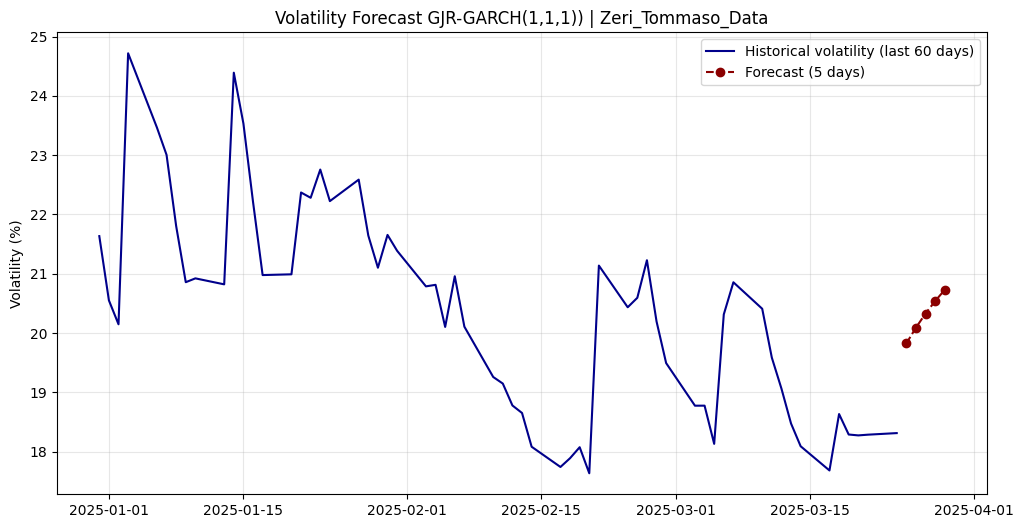

Volatility forecast for the next 5 days:
2025-03-25    19.82
2025-03-26    20.09
2025-03-27    20.33
2025-03-28    20.54
2025-03-29    20.73
Freq: D, dtype: float64
forecast for tomorrow is: 19.823%


In [13]:
# --- FORECAST STATICO OOS ANALITICO ---
# solo per GARCH, GJR-GARCH

# 1. Ricalcoliamo il forecast impostando l'orizzonte a 5
forecast = results.forecast(horizon=5)

# Estraiamo la volatilità (radice della varianza)
forecasted_variance = forecast.variance.values[-1, :]
forecasted_vol = np.sqrt(forecasted_variance)

# 2. Creiamo le date future per i 5 giorni
last_date = data.index[-1]
prediction_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=5, freq='D')

# 3. Creiamo la Series Pandas
forecast_series = pd.Series(forecasted_vol, index=prediction_dates)

# 4. PLOT
plt.figure(figsize=(12, 6))

# A. Plottiamo gli ultimi 60 giorni di storico
plt.plot(cond_vol.iloc[-60:].index, cond_vol.iloc[-60:], label="Historical volatility (last 60 days)", color="darkblue")

# B. Plottiamo la Previsione a 5 giorni
plt.plot(forecast_series.index, forecast_series, label="Forecast (5 days)", color="darkred", linestyle="--", marker="o")

plt.title(f"Volatility Forecast {modello_usato}) | {ticker}")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Volatility forecast for the next 5 days:")
print(forecast_series.round(2))

# Il primo valore della serie (indice 0) è la previsione per domani
volatilita_domani = forecast_series.iloc[0]

print(f"forecast for tomorrow is: {volatilita_domani:.3f}%")

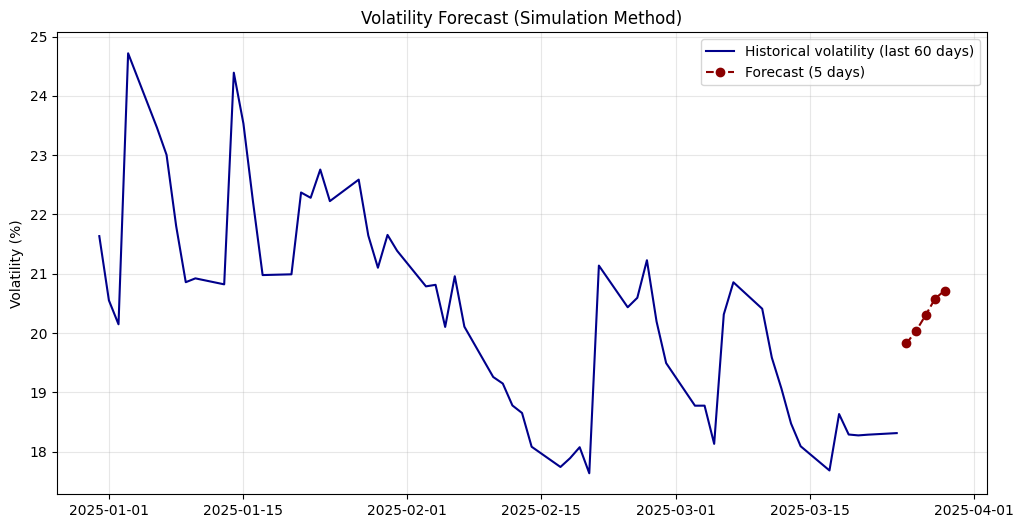

Volatility forecast for the next 5 days:
2025-03-25    19.82
2025-03-26    20.03
2025-03-27    20.30
2025-03-28    20.58
2025-03-29    20.72
Freq: D, dtype: float64
Forecast for tomorrow is: 19.823%


In [14]:
# --- FORECAST STATICO OOS MONTECARLO ---
# solo per TARCH, APARCH, EGARCH

# IMPORTANTE: Aggiungiamo method='simulation' perché per TARCH/APARCH (power != 2)
# il metodo analitico non funziona per orizzonti > 1.
forecast = results.forecast(horizon=5, method='simulation')

# Estraiamo la volatilità (radice della varianza)
# Nota: La simulazione restituisce già la varianza nel dataframe del forecast
forecasted_variance = forecast.variance.values[-1, :]
forecasted_vol = np.sqrt(forecasted_variance)

# --- 2. Creiamo le date future per i 5 giorni ---
last_date = data.index[-1]
prediction_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=5, freq='D')

# --- 3. Creiamo la Series Pandas ---
forecast_series = pd.Series(forecasted_vol, index=prediction_dates)

# --- 4. PLOT ---
plt.figure(figsize=(12, 6))

# A. Plottiamo gli ultimi 60 giorni di storico
plt.plot(cond_vol.iloc[-60:].index, cond_vol.iloc[-60:], label="Historical volatility (last 60 days)", color="darkblue")

# B. Plottiamo la Previsione a 5 giorni
plt.plot(forecast_series.index, forecast_series, label="Forecast (5 days)", color="darkred", linestyle="--", marker="o")

# Usa un titolo generico se le variabili 'modello_usato' o 'ticker' non sono definite nel blocco
plt.title(f"Volatility Forecast (Simulation Method)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Volatility forecast for the next 5 days:")
print(forecast_series.round(2))

# Il primo valore della serie (indice 0) è la previsione per domani
volatilita_domani = forecast_series.iloc[0]

print(f"Forecast for tomorrow is: {volatilita_domani:.3f}%")

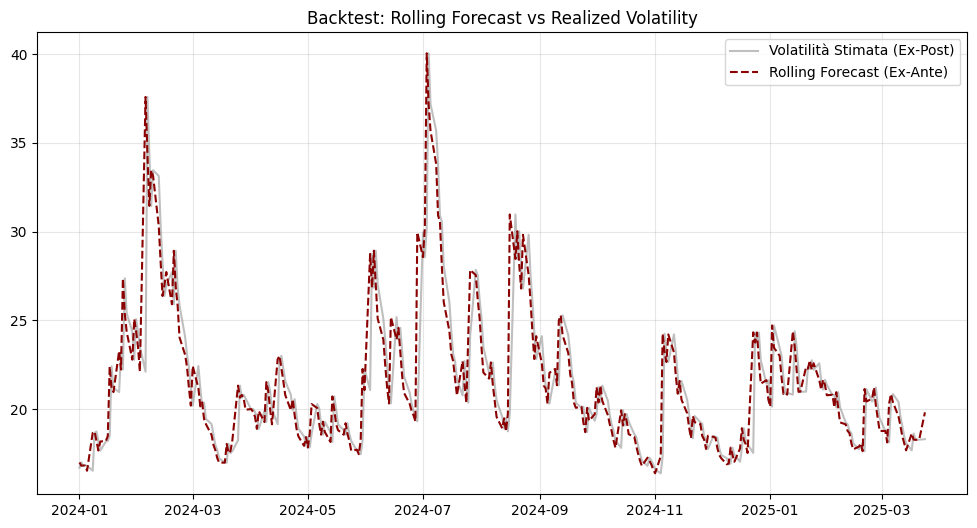

In [15]:
# --- FORECAST DINAMICO IS (Rolling) ---

# Scegliamo una data di partenza per il test (es. inizio 2024)
# horizon=1 perché nel rolling ci interessa solo "domani"
# NOTA: Assicurati che '2024-01-01' esista nei tuoi dati Excel, altrimenti cambia questa data!
rolling_forecast = results.forecast(start="2024-01-01", horizon=1)

# Estraiamo la varianza prevista (h.1) per ogni giorno dal 2024 a oggi
# dropna() rimuove i giorni prima del 2024 che non abbiamo calcolato
pred_vol_rolling = np.sqrt(rolling_forecast.variance.dropna()['h.1'])

# PLOT DI CONFRONTO
plt.figure(figsize=(12, 6))

# 1. Volatilità "Vera" (ex-post, quella calcolata su tutto il dataset)
# Usiamo quella del modello fittato su tutto come proxy della realtà
plt.plot(cond_vol.loc["2024-01-01":], label="Volatilità Stimata (Ex-Post)", color="grey", alpha=0.5)

# 2. La Previsione Rolling (quella che avresti avuto giorno per giorno)
plt.plot(pred_vol_rolling, label="Rolling Forecast (Ex-Ante)", color="darkred", linestyle="--")

plt.title("Backtest: Rolling Forecast vs Realized Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


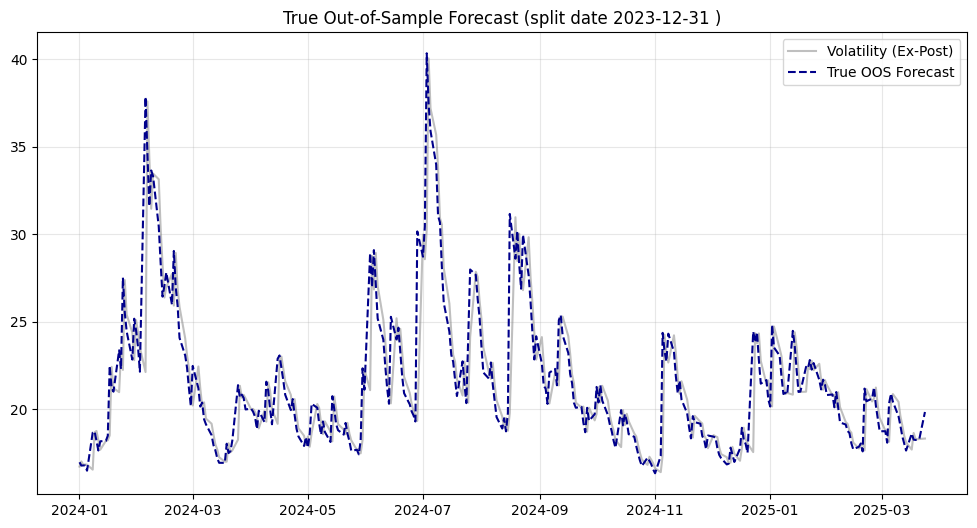

In [16]:
# --- FORECAST DINAMICO TRUE OOS ---

# Usiamo 'last_obs' per dire: "Calcola i parametri usando i dati SOLO fino alla fine del 2023"
# Tutto ciò che viene dopo è ignoto per il modello.
split_date = "2023-12-31"
results_oos = model.fit(last_obs=split_date, disp="off")

# --- 2. FORECAST SUL FUTURO (TEST SET) ---
# Ora chiediamo di prevedere dal 2024 in poi.
# Il modello userà i parametri "vecchi" (calcolati sul 2023) applicandoli ai dati nuovi man mano che arrivano.
forecast_oos = results_oos.forecast(start="2024-01-01", horizon=1)

# --- 3. ESTRAZIONE E PLOT (Uguale al tuo) ---
pred_vol_oos = np.sqrt(forecast_oos.variance.dropna()['h.1'])

plt.figure(figsize=(12, 6))

# Volatilità Realizzata (quella calcolata sull'intero dataset per confronto)
plt.plot(cond_vol.loc["2024-01-01":], label="Volatility (Ex-Post)", color="grey", alpha=0.5)

# La tua previsione OOS pura
plt.plot(pred_vol_oos, label="True OOS Forecast", color="darkblue", linestyle="--")

plt.title("True Out-of-Sample Forecast (split date 2023-12-31 )")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Calcolo dei modelli in corso...
- GARCH(1,1) completato.
- GJR-GARCH(1,1,1) completato.
- TARCH(1,1,1) completato.
- EGARCH(1,1,1) completato.
- APARCH(1,1,1) completato.


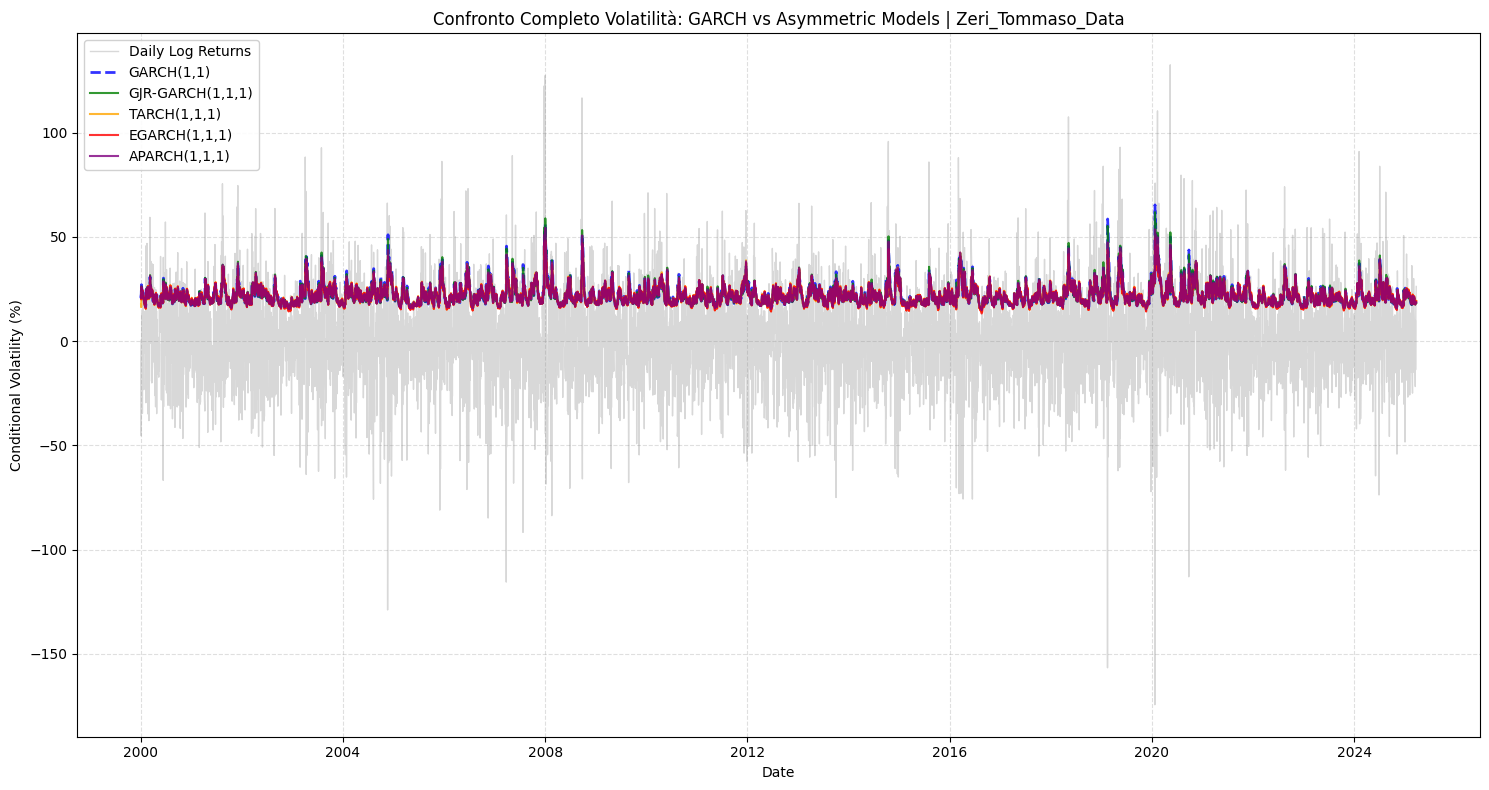

In [17]:
# --- MODELLI A CONFRONTO ---

# 1. Preparazione Dati
scaled_ret = data["logret"] * 100

# 2. Configurazione dei Modelli
models_config = {
    "GARCH(1,1)":       {"vol": "GARCH", "p": 1, "q": 1, "o": 0},
    "GJR-GARCH(1,1,1)": {"vol": "GARCH", "p": 1, "q": 1, "o": 1},
    "TARCH(1,1,1)":     {"vol": "GARCH", "p": 1, "q": 1, "o": 1, "power": 1.0},
    "EGARCH(1,1,1)":    {"vol": "EGARCH", "p": 1, "q": 1, "o": 1},
    "APARCH(1,1,1)":    {"vol": "APARCH", "p": 1, "q": 1, "o": 1}
}

# Dizionario per memorizzare i risultati calcolati
results_store = {}

print("Calcolo dei modelli in corso...")

# 3. Calcolo (Fitting)
for name, params in models_config.items():
    # Fit del modello
    model = arch_model(scaled_ret, **params)
    res = model.fit(disp="off")
    # Salviamo la serie della volatilità
    results_store[name] = res.conditional_volatility
    print(f"- {name} completato.")

# 4. PLOT UNICO COMPARATIVO
plt.figure(figsize=(15, 8)) # Grafico più grande per vedere i dettagli

# A. Sfondo: Rendimenti giornalieri
plt.plot(scaled_ret.index, scaled_ret, label="Daily Log Returns", color="grey", alpha=0.3, linewidth=1)

# B. Linee di Volatilità (Colori diversi)
colors = ['blue', 'green', 'orange', 'red', 'purple'] # Assegniamo un colore a ogni modello

for (name, vol_data), color in zip(results_store.items(), colors):
    # Usiamo linee leggermente diverse per distinguerle se si sovrappongono
    linestyle = '-'
    linewidth = 1.5

    # Rendiamo il GARCH base un po' più sottile o tratteggiato per confronto
    if name == "GARCH(1,1)":
        linestyle = '--'
        linewidth = 2.0

    plt.plot(vol_data.index, vol_data, label=name, color=color, linewidth=linewidth, linestyle=linestyle, alpha=0.8)

# C. Formattazione Finale
plt.title(f"Confronto Completo Volatilità: GARCH vs Asymmetric Models | {ticker}")
plt.ylabel("Conditional Volatility (%)")
plt.xlabel("Date")
plt.legend(loc='upper left', frameon=True, fancybox=True, framealpha=0.9) # Legenda ben visibile
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()


Inizio Backtest OOS (Training fino al 2023-12-31)...
Processing GARCH(1,1)...
Processing GJR-GARCH(1,1,1)...
Processing TARCH(1,1,1)...
Processing EGARCH(1,1,1)...
Processing APARCH(1,1,1)...
Calcoli completati.



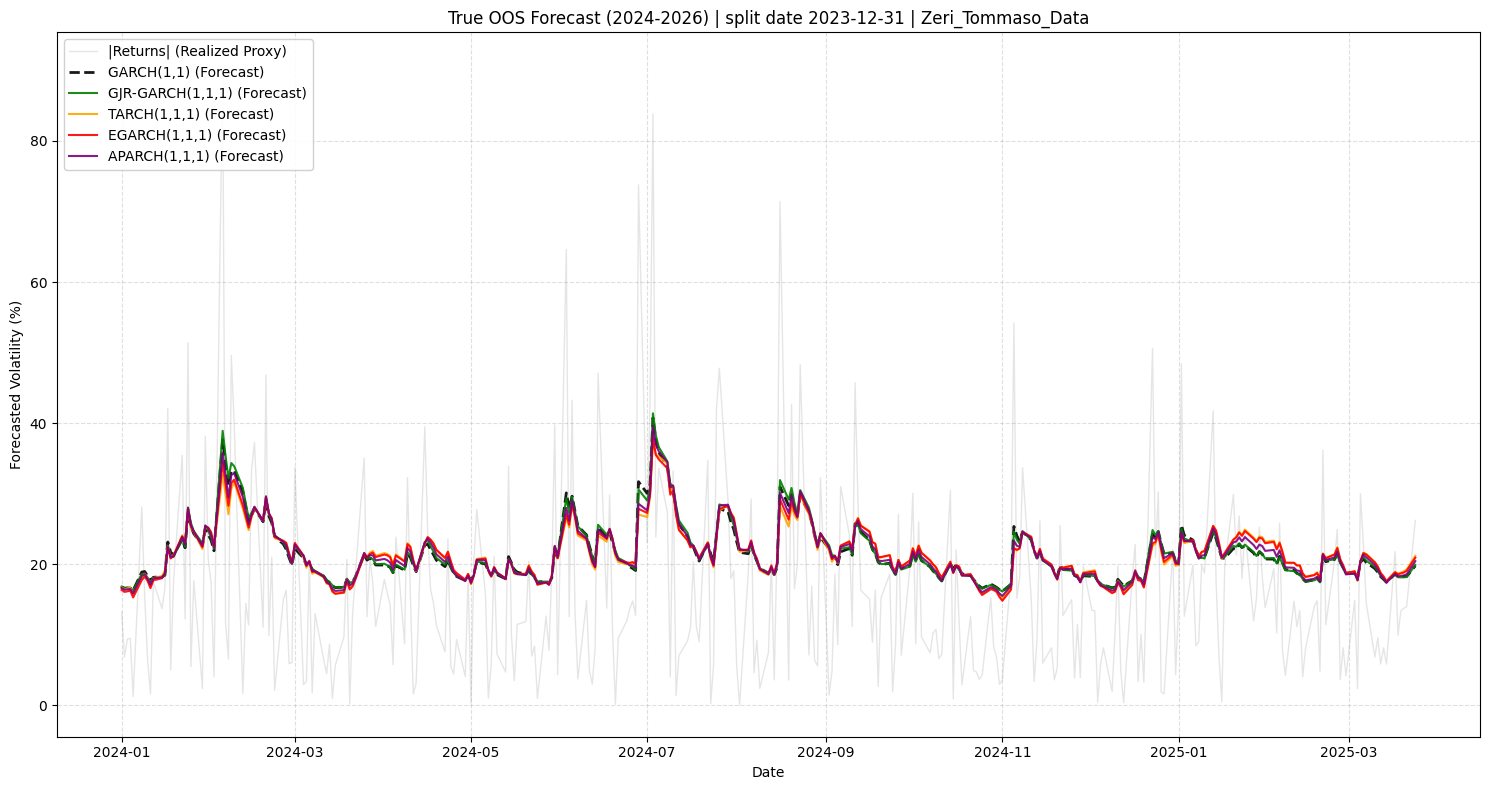

In [18]:
# --- DYNAMIC FORECASTS OOS A CONFRONTO ---

# --- 1. CONFIGURAZIONE ---
# Assumiamo che 'scaled_ret' e 'modelli_config' siano già definiti come nei passaggi precedenti.
# Se non lo fossero, li riprendiamo velocemente dal dizionario che abbiamo fatto prima.
if 'modelli_config' not in locals():
    modelli_config = {
        "GARCH(1,1)":       {"vol": "GARCH", "p": 1, "q": 1, "o": 0},
        "GJR-GARCH(1,1,1)": {"vol": "GARCH", "p": 1, "q": 1, "o": 1},
        "TARCH(1,1,1)":     {"vol": "GARCH", "p": 1, "q": 1, "o": 1, "power": 1.0},
        "EGARCH(1,1,1)":    {"vol": "EGARCH", "p": 1, "q": 1, "o": 1},
        "APARCH(1,1,1)":    {"vol": "APARCH", "p": 1, "q": 1, "o": 1}
    }

# Date per il taglio
split_date = "2023-12-31"      # Ultimo giorno di training
start_forecast = "2024-01-01"  # Primo giorno di previsione

oos_results = {}

print(f"Inizio Backtest OOS (Training fino al {split_date})...")

# --- 2. CICLO DI TRAINING E FORECAST ---
for nome_modello, params in modelli_config.items():
    print(f"Processing {nome_modello}...")

    # A. Definizione del modello (sull'intero dataset)
    model = arch_model(scaled_ret, **params)

    # B. FIT con 'last_obs': Congela i parametri al 2023!
    res_oos = model.fit(last_obs=split_date, disp="off")

    # C. FORECAST: Prevediamo dal 2024 in poi
    # IMPORTANTE: Usiamo method='simulation' per evitare errori con TARCH/APARCH
    # e bias con EGARCH.
    forecast = res_oos.forecast(start=start_forecast, horizon=1, method='simulation')

    # D. Estrazione
    # Prendiamo la varianza prevista, radice quadrata -> volatilità
    # .dropna() rimuove i NaN del periodo di training (prima del 2024)
    pred_vol = np.sqrt(forecast.variance.dropna()['h.1'])

    oos_results[nome_modello] = pred_vol

print("Calcoli completati.\n")

# --- 3. PLOT COMPARATIVO OOS ---
plt.figure(figsize=(15, 8))

# A. Sfondo: Proxy della volatilità reale (Valore assoluto dei rendimenti nel 2024+)
# Questo ci serve per vedere visivamente "quanto si è mosso davvero" il mercato
real_proxy = scaled_ret.loc[start_forecast:].abs()
plt.plot(real_proxy.index, real_proxy, label="|Returns| (Realized Proxy)",
         color="grey", alpha=0.2, linewidth=1)

# B. Plot delle Previsioni dei Modelli
colors = ['blue', 'green', 'orange', 'red', 'purple']

for (name, vol_series), color in zip(oos_results.items(), colors):
    linewidth = 1.5
    linestyle = '-'

    # Tratteggiamo il GARCH classico per distinguerlo meglio
    if name == "GARCH(1,1)":
        linestyle = '--'
        linewidth = 2.0
        color = 'black'

    plt.plot(vol_series.index, vol_series, label=f"{name} (Forecast)",
             color=color, linewidth=linewidth, linestyle=linestyle, alpha=0.9)

plt.title(f"True OOS Forecast (2024-2026) | split date {split_date} | {ticker}")
plt.ylabel("Forecasted Volatility (%)")
plt.xlabel("Date")
plt.legend(loc='upper left', frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()